<a href="https://colab.research.google.com/github/aliawan7november/Encapsulation/blob/main/Ali%20Awan_149_roll_number_sp23_BSCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- EXPECTED OUTPUT ---
1. Value of the line integral: 1.0000

2. Fourier coefficients:
   b_1 = 1.0
   b_2 = 0.0
   b_3 = -0.0
   b_4 = -0.0

3. Generating plot below...


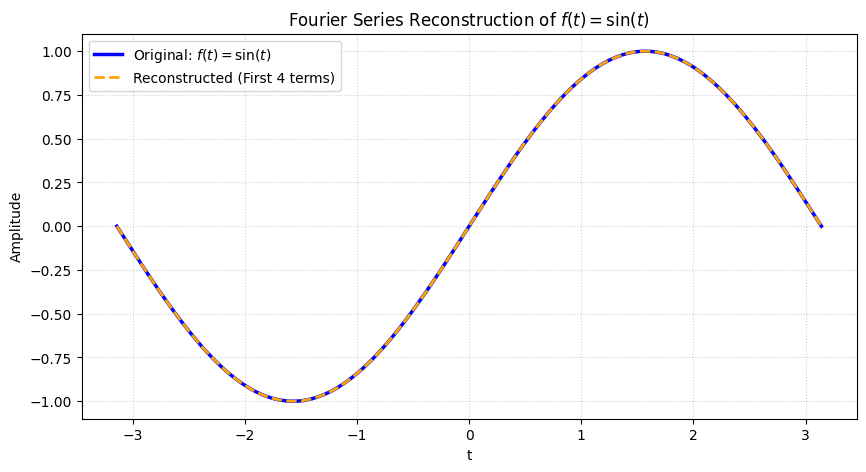

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ==========================================
# PART 1: Line Integral Approximation
# ==========================================
# Path: y = x^2  -> dy = 2x dx, from x=0 to x=1
# Force Field: F(x, y) = y*i + x*j
# F . dr = M dx + N dy = (y)dx + (x)dy
# Substituting y = x^2 and dy = 2x dx:
# F . dr = (x^2)dx + x*(2x dx) = 3x^2 dx

def line_integral_integrand(x):
    return 3 * x**2

# Compute numerical line integral from x=0 to x=1
line_integral_val, _ = quad(line_integral_integrand, 0, 1)


# ==========================================
# PART 2: Fourier Series Coefficients
# ==========================================
# Signal: f(t) = sin(t) on [-pi, pi]
# Since sin(t) is an odd function, all a_0 and a_n coefficients are 0.
# The b_n coefficients are calculated using: b_n = (1/pi) * integral from -pi to pi of sin(t)*sin(n*t) dt

# Function to compute b_n numerically
def compute_bn(n):
    integrand = lambda t: np.sin(t) * np.sin(n * t)
    val, _ = quad(integrand, -np.pi, np.pi)
    return (1 / np.pi) * val

# Compute the first 4 Fourier coefficients (n = 1, 2, 3, 4)
# Note: Physically, for sin(t), b_1 = 1 and b_2 = b_3 = b_4 = 0 due to orthogonality.
fourier_coeffs = {f"b_{n}": round(compute_bn(n), 4) for n in range(1, 5)}


# ==========================================
# PART 3: Signal Reconstruction & Plotting
# ==========================================
t_vals = np.linspace(-np.pi, np.pi, 500)
original_signal = np.sin(t_vals)

# Reconstruct using the first 4 coefficients
reconstructed_signal = np.zeros_like(t_vals)
for n in range(1, 5):
    bn = compute_bn(n)
    reconstructed_signal += bn * np.sin(n * t_vals)


# ==========================================
# PRINT EXPECTED OUTPUTS
# ==========================================
print("--- EXPECTED OUTPUT ---")
print(f"1. Value of the line integral: {line_integral_val:.4f}\n")

print("2. Fourier coefficients:")
for coeff, val in fourier_coeffs.items():
    print(f"   {coeff} = {val}")
print("\n3. Generating plot below...")

# Plotting the Original vs Reconstructed Signal
plt.figure(figsize=(10, 5))
plt.plot(t_vals, original_signal, label='Original: $f(t) = \\sin(t)$', color='blue', linewidth=2.5)
plt.plot(t_vals, reconstructed_signal, label='Reconstructed (First 4 terms)', color='orange', linestyle='--', linewidth=2)
plt.title('Fourier Series Reconstruction of $f(t) = \\sin(t)$')
plt.xlabel('t')
plt.ylabel('Amplitude')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()